## ICESAT-2 exploration

In [25]:
import h5py
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# WORLD Z10 box scheme (38639 boxes)
# p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet

In [2]:
# https://nsidc.org/data/atl03/versions/6, ICESat-2
# Used NASA EarthData Search to draw an AOI in the WaddenSea and select a random track; downloaded to local storage

# DOCS: https://nsidc.org/data/atl24/versions/1#anchor-documentation: https://nsidc.org/sites/default/files/documents/user-guide/atl24-v001-userguide.pdf

# We need (filters) for all the beams:
# class_ph = 40 (bathymetry)
# confidence > 0.6 (see also low_confidence_flag)
# sensor_depth_exceeded = 0 (reasonable)
# delta_time
# ellipse_h (in m)
# ortho_h (in m)
# lat_ph
# lon_ph
# sigma_tvu
# sigma_thu

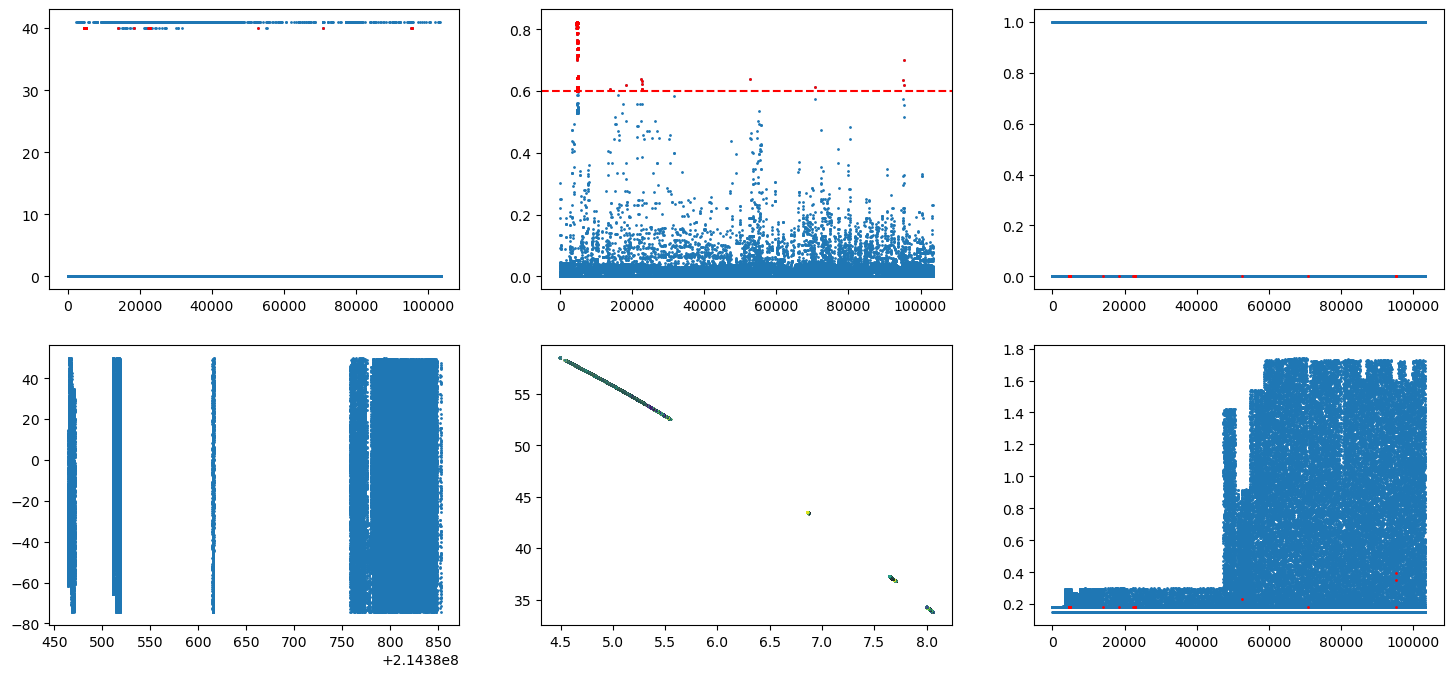

In [38]:
# testing for one file
pdrive = r"p:\11209821-cmems-global-sdb\00_miscellaneous\ICESAT-2"
granule = "ATL24_20241017060548_04732502_006_01_001_01.h5"

# open the HDF5 file
import h5py
with h5py.File(os.path.join(pdrive, granule), "r") as f:
    # print the names of the groups in the file
    # print("Groups:")
    # for group in f.keys():
    #     print(group)

    # # print the names of the datasets in the six beams (gt1l-gt3r)
    # print("\nDatasets:")
    # for dataset in f["gt1l"].keys():
    #     print(dataset)

    # read specific dataset variables (10 of 19)
    gt1l_cph = f["gt1l"]["class_ph"]
    gt1l_conf = f["gt1l"]["confidence"]
    gt1l_sde = f["gt1l"]["sensor_depth_exceeded"]
    gt1l_dt = f["gt1l"]["delta_time"]
    gt1l_eh = f["gt1l"]["ellipse_h"]
    gt1l_oh = f["gt1l"]["ortho_h"]
    gt1l_lat = f["gt1l"]["lat_ph"]
    gt1l_lon = f["gt1l"]["lon_ph"]
    gt1l_stvu = f["gt1l"]["sigma_tvu"]
    gt1l_sthu = f["gt1l"]["sigma_thu"]

    # put in the filters described above
    mask_list = (gt1l_cph[:] == 40) & (gt1l_conf[:] > 0.6) & (gt1l_sde[:] == 0)
    masked_xaxis = np.arange(len(gt1l_cph[:]))[mask_list]
    gt1l_cph_masked = gt1l_cph[mask_list]
    gt1l_conf_masked = gt1l_conf[mask_list]
    gt1l_sde_masked = gt1l_sde[mask_list]
    gt1l_dt_masked = gt1l_dt[mask_list]
    gt1l_eh_masked = gt1l_eh[mask_list]
    gt1l_oh_masked = gt1l_oh[mask_list]
    gt1l_lat_masked = gt1l_lat[mask_list]
    gt1l_lon_masked = gt1l_lon[mask_list]
    gt1l_stvu_masked = gt1l_stvu[mask_list]
    gt1l_sthu_masked = gt1l_sthu[mask_list]

    # plotting
    fig, axs = plt.subplots(2, 3, figsize=(18, 8))
    axs[0,0].plot(range(len(gt1l_cph[:])), gt1l_cph[:], "o", markersize=1)  
    axs[0,0].plot(masked_xaxis, gt1l_cph_masked, "o", markersize=1, color='red', label='Filtered')

    axs[0,1].plot(range(len(gt1l_conf[:])), gt1l_conf[:],"o", markersize=1)
    axs[0,1].plot(masked_xaxis, gt1l_conf_masked, "o", markersize=1, color='red', label='Filtered')
    axs[0,1].axhline(y=0.6, color='r', linestyle='--', label='Confidence Threshold')

    axs[0,2].plot(range(len(gt1l_sde[:])), gt1l_sde[:], "o", markersize=1)
    axs[0,2].plot(masked_xaxis, gt1l_sde_masked, "o", markersize=1, color='red', label='Filtered')

    axs[1,0].plot(gt1l_dt[:], gt1l_oh[:], "o", markersize=1)


    axs[1,1].scatter(gt1l_lon[:], gt1l_lat[:], s=1, c=gt1l_oh[:], cmap='viridis')

    axs[1,2].plot(range(len(gt1l_stvu[:])), gt1l_stvu[:], "o", markersize=1)
    axs[1,2].plot(masked_xaxis, gt1l_stvu_masked, "o", markersize=1, color='red', label='Filtered')